# Автоматическое улучшение изображений на стороне браузера
## Обучение компактной ML-модели для коррекции яркости, контраста и цветности

**Курсовой проект.** Цель работы — построить систему, которая улучшает фотографии в реальном времени прямо в браузере пользователя, без отправки данных на сервер. Улучшение выполняется по трём параметрам: **яркость**, **контрастность** и **цветность (насыщенность)**.

---

### Идея решения

Прямой подход — обучить нейросеть, которая по входному изображению строит улучшенное изображение целиком (image-to-image). Но такие модели тяжёлые (десятки мегабайт) и медленные, что плохо совместимо с запуском в браузере и с ограничением «весь код решения ≤ 10 МБ».

Поэтому используется более экономная схема, разделяющая «интеллект» и «исполнение»:

> Нейросеть **анализирует** изображение и предсказывает всего **три числа** — коэффициенты коррекции яркости, контраста и насыщенности. Применение этих коэффициентов к полному изображению выполняет простой и быстрый алгоритм (его несложно перенести в браузер на чистом JavaScript).

Преимущества: модель получается очень компактной (около 1 МБ), быстро работает даже без видеокарты, не нагружает память и процессор и легко запускается через TensorFlow.js. Это напрямую отвечает критериям оценки: размер решения, скорость, экономия CPU и RAM.

### Тип задачи

Перед нами **регрессия**: вход — изображение, выход — три вещественных коэффициента. В отличие от классификации (как в учебной задаче о Титанике, где предсказывается класс «выжил / не выжил»), здесь мы предсказываем непрерывные величины.

### Как получаются обучающие данные

Готового набора «плохое фото → правильные коэффициенты коррекции» не существует. Поэтому применяется приём **самообучения на синтетических искажениях**:

1. Берём набор **эталонных** (профессионально обработанных) фотографий — датасет MIT-Adobe FiveK, версия эксперта `a`.
2. **Искусственно ухудшаем** каждое фото: случайно меняем яркость, контраст и насыщенность. Поскольку мы сами задаём степень ухудшения, нам точно известны и **обратные** коэффициенты, возвращающие фото к эталону.
3. Обучаем модель по ухудшенному изображению предсказывать эти коэффициенты восстановления.

### Структура работы

1. Окружение и данные.
2. Разведочный анализ эталонных изображений (EDA).
3. Модель синтетической деградации.
4. Конвейер подготовки данных.
5. Сравнение семейств моделей (классические алгоритмы на признаках).
6. Нейросетевая модель и её обучение.
7. Оценка качества.
8. Экспорт модели в TensorFlow.js.


# 1. Окружение и данные

## 1.1. Проверка вычислительных ресурсов

Обучение выполняется в Google Colab. Наличие видеокарты (GPU) ускоряет обучение в десятки раз. Если GPU не подключена, её можно включить в меню `Среда выполнения → Сменить среду выполнения → T4 GPU`.


In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus[0].name if gpus else "не найдена (будет использован CPU)")


TensorFlow: 2.20.0
GPU: /physical_device:GPU:0


## 1.2. Параметры проекта

Из шести вариантов обработки в датасете FiveK (исходные «сырые» снимки `raw` и пять экспертных версий `a`–`e`) в качестве эталона выбрана версия эксперта `a`. Используется **полный набор — все 5000 фотографий**: достаточный объём данных принципиально важен, иначе модель переобучается на содержимое и теряет обобщающую способность.


In [24]:
from pathlib import Path
import numpy as np

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

EXPERT     = "a"            # экспертная версия-эталон
IMG_SIZE   = 224      # было 192
TRAIN_BASE = 240      # было 208
BATCH      = 64       # было 32 — крупнее батч сгладит кривую и BatchNorm
IMG_EXT    = {".jpg", ".jpeg", ".png"}
KAGGLE_DATASET = "weipengzhang/adobe-fivek"

# Рабочая папка сессии и постоянное хранилище на Google Drive
WORK_DIR  = Path("/content/expert_a")
DRIVE_DIR = Path("/content/drive/MyDrive/photo_enhancer")
TAR_CACHE = DRIVE_DIR / "expert_a_full.tar"     # архив с эталонами (чтобы не качать 26 ГБ повторно)
MODELS_DIR = DRIVE_DIR / "models"

print("Эксперт:", EXPERT, "| вход модели:", IMG_SIZE, "px | весь набор эксперта a")


Эксперт: a | вход модели: 224 px | весь набор эксперта a


## 1.3. Получение данных

Датасет FiveK на Kaggle поставляется единым архивом объёмом около 26 ГБ, и выгрузить из него «только папку `a`» одной командой нельзя. Поэтому реализована экономичная схема: архив скачивается **один раз**, из него извлекаются только изображения эксперта `a`, после чего они сохраняются на Google Drive отдельным архивом. При последующих запусках данные берутся с Drive, и повторная загрузка 26 ГБ уже не требуется.


In [25]:
import os, zipfile, tarfile
from google.colab import drive

drive.mount("/content/drive")
DRIVE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

def local_count():
    return sum(1 for p in WORK_DIR.glob("*") if p.suffix.lower() in IMG_EXT) if WORK_DIR.exists() else 0

if local_count() > 4000:
    print("Изображения уже распакованы в этой сессии:", local_count())

elif TAR_CACHE.exists():
    print("Восстанавливаю эталоны из кэша на Google Drive...")
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    with tarfile.open(TAR_CACHE, "r") as tar:
        tar.extractall(WORK_DIR)
    print("Готово, изображений:", local_count())

else:
    print("Кэша нет — скачиваю датасет с Kaggle (~26 ГБ, единоразово).")
    from google.colab import files
    print("Загрузите ключ kaggle.json (Kaggle -> Settings -> API -> Create New Token):")
    files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    !cp kaggle.json /root/.kaggle/kaggle.json
    !chmod 600 /root/.kaggle/kaggle.json
    !pip install -q kaggle
    !kaggle datasets download -d {KAGGLE_DATASET} -p /content

    zip_path = next(Path("/content").glob("*.zip"))
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path) as zf:
        members = [n for n in zf.namelist()
                   if not n.endswith("/") and Path(n).suffix.lower() in IMG_EXT
                   and EXPERT in Path(n).parts[:-1]]
        for m in members:
            (WORK_DIR / Path(m).name).write_bytes(zf.read(m))
    zip_path.unlink()
    print("Извлечено изображений эксперта a:", local_count())

    print("Сохраняю кэш-архив на Google Drive (чтобы больше не качать 26 ГБ)...")
    with tarfile.open(TAR_CACHE, "w") as tar:
        for p in WORK_DIR.glob("*"):
            if p.suffix.lower() in IMG_EXT:
                tar.add(p, arcname=p.name)
    print("Кэш сохранён:", TAR_CACHE)

all_paths = sorted(p for p in WORK_DIR.glob("*") if p.suffix.lower() in IMG_EXT)
print("Всего эталонных изображений:", len(all_paths))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Изображения уже распакованы в этой сессии: 5000
Всего эталонных изображений: 5000


## 1.4. Разделение на обучающую, валидационную и тестовую выборки

Данные делятся на три непересекающиеся части: **обучающую** (80 %), на которой модель учится; **валидационную** (10 %), по которой отслеживается обучение и выбираются лучшие веса; и **тестовую** (10 %), которая используется только для финальной честной оценки. Каждая фотография попадает ровно в одну выборку.


In [26]:
from sklearn.model_selection import train_test_split
import pandas as pd

names = [p.name for p in all_paths]
train_names, temp_names = train_test_split(names, test_size=0.20, random_state=SEED, shuffle=True)
val_names, test_names   = train_test_split(temp_names, test_size=0.50, random_state=SEED, shuffle=True)

def to_df(ns):
    return pd.DataFrame({"image_name": ns, "image_path": [str(WORK_DIR / n) for n in ns]}).reset_index(drop=True)

train_df, val_df, test_df = to_df(train_names), to_df(val_names), to_df(test_names)
print("Обучающая :", len(train_df))
print("Валидация :", len(val_df))
print("Тестовая  :", len(test_df))

inter = (set(train_df.image_name) & set(val_df.image_name)) | (set(train_df.image_name) & set(test_df.image_name)) | (set(val_df.image_name) & set(test_df.image_name))
print("Пересечений между выборками:", len(inter))


Обучающая : 4000
Валидация : 500
Тестовая  : 500
Пересечений между выборками: 0


# 2. Разведочный анализ данных (EDA)

Прежде чем строить модель, важно понять характер эталонных фотографий. Если измерить их яркость, контраст и насыщенность, мы получим «эталонную норму» — то, как выглядит *хорошо обработанное* фото эксперта `a`. Именно от этой нормы мы будем затем синтетически отклонять изображения, а модель будет учиться возвращать их обратно. Распределения этих характеристик — фундамент всей дальнейшей работы.

Сначала визуально оценим несколько случайных изображений выборки.


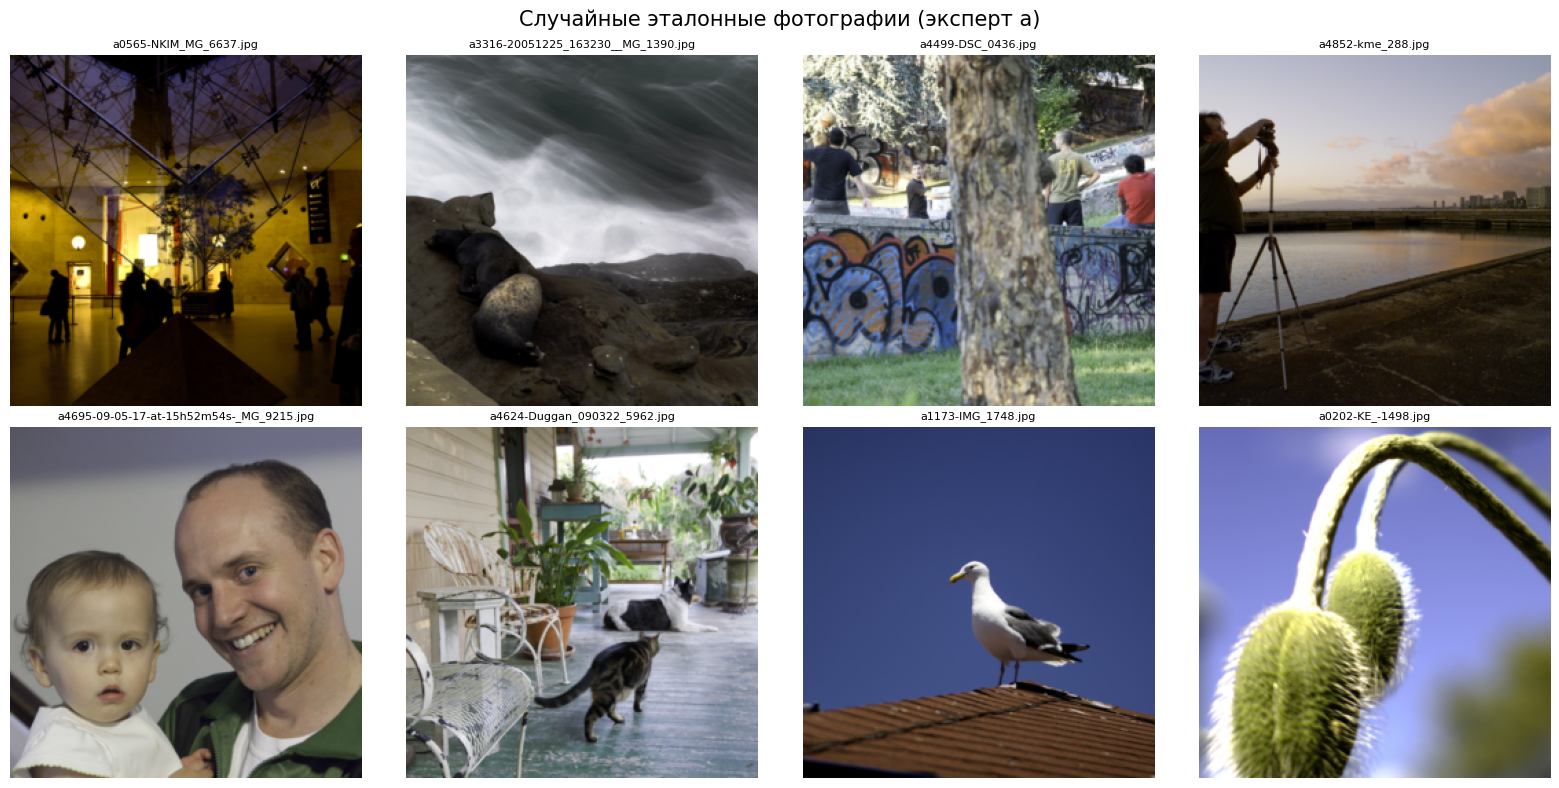

In [27]:
import matplotlib.pyplot as plt
from PIL import Image
rng = np.random.default_rng(SEED)

def load_square(path, size):
    im = Image.open(path).convert("RGB")
    w, h = im.size; s = min(w, h)
    im = im.crop(((w - s)//2, (h - s)//2, (w - s)//2 + s, (h - s)//2 + s)).resize((size, size), Image.BILINEAR)
    return np.asarray(im, np.uint8)

idx = rng.choice(len(train_df), size=8, replace=False)
plt.figure(figsize=(16, 8))
for k, j in enumerate(idx):
    plt.subplot(2, 4, k + 1)
    plt.imshow(load_square(train_df.image_path[j], 256)); plt.axis("off")
    plt.title(train_df.image_name[j], fontsize=8)
plt.suptitle("Случайные эталонные фотографии (эксперт a)", fontsize=15)
plt.tight_layout(); plt.show()


## 2.1. Измерение характеристик

Для каждого изображения (уменьшенного до 128 px ради скорости) вычисляются три величины:

- **Яркость** — средняя светлота пикселей по формуле `0.299·R + 0.587·G + 0.114·B`; 0 — чёрное, 1 — белое.
- **Контраст** — стандартное отклонение яркости (насколько велик разброс светлот).
- **Насыщенность** — средняя «сочность» цвета (канал S цветовой модели HSV); 0 — серое, 1 — предельно насыщенное.

Чтобы не считать статистику по всем 5000 фото, возьмём представительную подвыборку.


In [28]:
from matplotlib.colors import rgb_to_hsv

def image_stats(arr01):
    luma = 0.299*arr01[..., 0] + 0.587*arr01[..., 1] + 0.114*arr01[..., 2]
    sat  = rgb_to_hsv(arr01)[..., 1]
    return float(luma.mean()), float(luma.std()), float(sat.mean())

eda_sample = train_df.sample(n=min(1500, len(train_df)), random_state=SEED)
rows = []
for p in eda_sample.image_path:
    arr = load_square(p, 128).astype(np.float32) / 255.0
    b, c, s = image_stats(arr)
    rows.append({"brightness": b, "contrast": c, "saturation": s})
stats_df = pd.DataFrame(rows)
stats_df.describe().round(3)


,brightness,contrast,saturation
count,1500.000,1500.000,1500.000
mean,0.339,0.207,0.277
std,0.109,0.058,0.136
min,0.043,0.048,0.015
25%,0.264,0.169,0.178
50%,0.335,0.204,0.255
75%,0.411,0.243,0.345
max,0.787,0.421,0.950


## 2.2. Гипотезы об эталонных фотографиях

Сформулируем три гипотезы о том, как должны выглядеть характеристики профессионально обработанных снимков, и проверим их распределениями.

**Гипотеза 1 (яркость).** Эталонные фото не должны быть массово пере- или недосвеченными: средняя яркость концентрируется в средней зоне, а не у краёв 0 и 1.

**Гипотеза 2 (контраст).** Контраст у эталонов умеренный и достаточно стабильный — без «плоских» и без перегруженных кадров.

**Гипотеза 3 (насыщенность).** Цвета живые, но без чрезмерности; насыщенность сосредоточена в умеренной зоне.


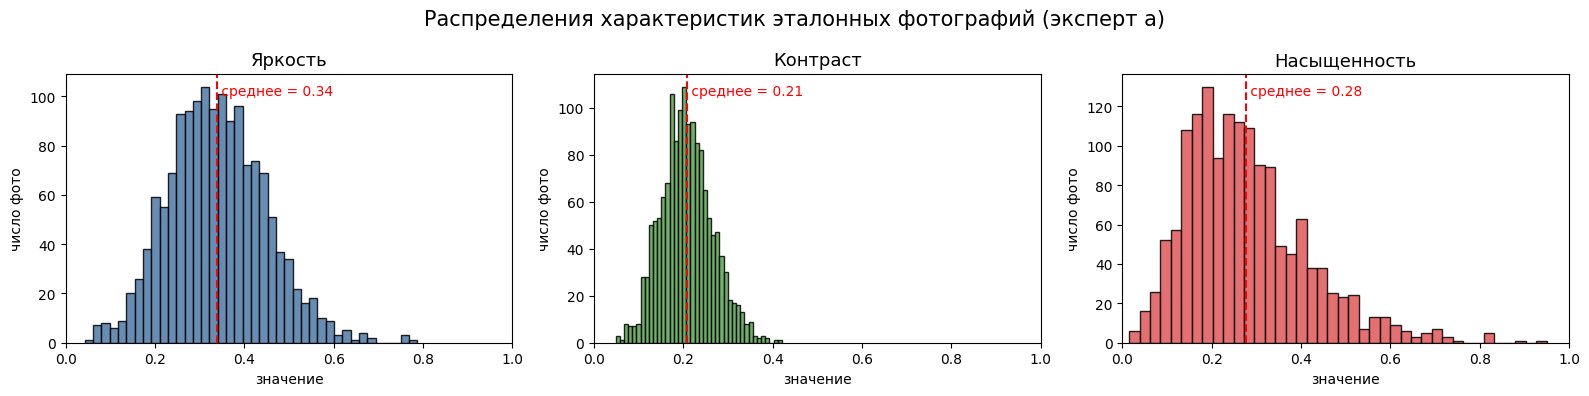

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
spec = [("brightness", "Яркость", "#4e79a7"),
        ("contrast",   "Контраст", "#59a14f"),
        ("saturation", "Насыщенность", "#e15759")]
for ax, (col, name, color) in zip(axes, spec):
    ax.hist(stats_df[col], bins=40, color=color, edgecolor="black", alpha=0.85)
    m = stats_df[col].mean()
    ax.axvline(m, color="red", linestyle="--", linewidth=1.5)
    ax.text(m, ax.get_ylim()[1]*0.92, f" среднее = {m:.2f}", color="red")
    ax.set_title(name, fontsize=13); ax.set_xlabel("значение"); ax.set_ylabel("число фото"); ax.set_xlim(0, 1)
plt.suptitle("Распределения характеристик эталонных фотографий (эксперт a)", fontsize=15)
plt.tight_layout(); plt.show()


## 2.3. Выводы по EDA

Наблюдаемые распределения по выборке эталонов эксперта `a`:

- **Яркость** сосредоточена в средней зоне (среднее около 0.34, основная масса в диапазоне ≈0.25–0.40), экстремальные пере- и недосветы единичны. Гипотеза 1 подтверждается; при этом видно, что стиль эксперта `a` — умеренно тёмный, без выбеливания.
- **Контраст** стабильно умеренный: среднее около 0.21 при небольшом разбросе. Гипотеза 2 подтверждается.
- **Насыщенность** в среднем умеренная (около 0.28), но с заметным разбросом — встречаются и приглушённые, и сочные кадры. Гипотеза 3 подтверждается частично.

Таким образом, «эталонная норма» эксперта `a` — это умеренно тёмные, средне-контрастные и средне-насыщенные изображения. Именно к такому виду модель будет приводить входные фотографии. На следующем шаге мы будем намеренно уводить изображения из этой нормы, точно зная коэффициенты возврата, — и эти коэффициенты станут целевой переменной обучения.


# 3. Модель синтетической деградации

Здесь определяется, как формируются обучающие пары: исходное эталонное изображение случайно «портится», а в качестве ответа запоминаются коэффициенты, восстанавливающие оригинал.

### Согласованность с браузером

Математика искажения и восстановления намеренно выбрана такой, чтобы её можно было **точно повторить в браузере**:

- **яркость** — умножение всех каналов на коэффициент;
- **контраст** — растяжение/сжатие значений относительно **средней яркости кадра** (а не относительно фиксированной середины). Так изменение контраста не сдвигает общую яркость — яркость и контраст остаются независимыми, что упрощает задачу для модели;
- **насыщенность** — смешивание цвета с его серой (яркостной) версией.

### Кодирование цели

В качестве ответа модель предсказывает не сами множители, а их **логарифмы**. Причина: усиление «в 1.3 раза» и ослабление «в 1.3 раза» (то есть ×0.77) несимметричны как числа (1.3 и 0.77), но симметричны в логарифме (+0.26 и −0.26). Для регрессии это удобнее — ошибки в обе стороны весят одинаково, и обучение идёт ровнее. В браузере достаточно взять экспоненту от предсказания, чтобы получить готовый множитель.

### Диапазоны искажений

Яркость и контраст изменяются в пределах ×0.7…1.3, насыщенность — ×0.6…1.4. Эти же границы служат «предохранителями» при применении коррекции в браузере.


In [30]:
BRIGHTNESS_RANGE = (0.7, 1.3)
CONTRAST_RANGE   = (0.7, 1.3)
SATURATION_RANGE = (0.6, 1.4)

def _luma(x):
    return 0.299*x[..., 0:1] + 0.587*x[..., 1:2] + 0.114*x[..., 2:3]

def apply_adjust(img, f_bright, f_contrast, f_sat):
    # Применение коррекции; та же логика будет воспроизведена в браузере
    x = img * f_bright
    pivot = tf.reduce_mean(_luma(x), axis=[0, 1], keepdims=True)   # средняя яркость кадра
    x = (x - pivot) * f_contrast + pivot                          # контраст вокруг средней
    gray = _luma(x)
    x = gray + (x - gray) * f_sat                                 # насыщенность
    return tf.clip_by_value(x, 0.0, 1.0)

def sample_degradation():
    fb = tf.random.uniform([], *BRIGHTNESS_RANGE)
    fc = tf.random.uniform([], *CONTRAST_RANGE)
    fs = tf.random.uniform([], *SATURATION_RANGE)
    return fb, fc, fs

def encode_restore_target(fb, fc, fs):
    # Цель — логарифмы коэффициентов восстановления (обратных к коэффициентам порчи)
    return tf.stack([tf.math.log(1.0/fb), tf.math.log(1.0/fc), tf.math.log(1.0/fs)])

# Версии на NumPy — для классических моделей и визуализации
def np_apply_adjust(img, fb, fc, fs):
    x = img * fb
    pivot = (0.299*x[..., 0] + 0.587*x[..., 1] + 0.114*x[..., 2]).mean()
    x = (x - pivot) * fc + pivot
    gray = (0.299*x[..., 0] + 0.587*x[..., 1] + 0.114*x[..., 2])[..., None]
    x = gray + (x - gray) * fs
    return np.clip(x, 0.0, 1.0)

print("Функции деградации и кодирования цели определены.")


Функции деградации и кодирования цели определены.


Проверим визуально: оригинал и его ухудшенная версия с указанием коэффициентов, которые должны вернуть картинку к эталону.

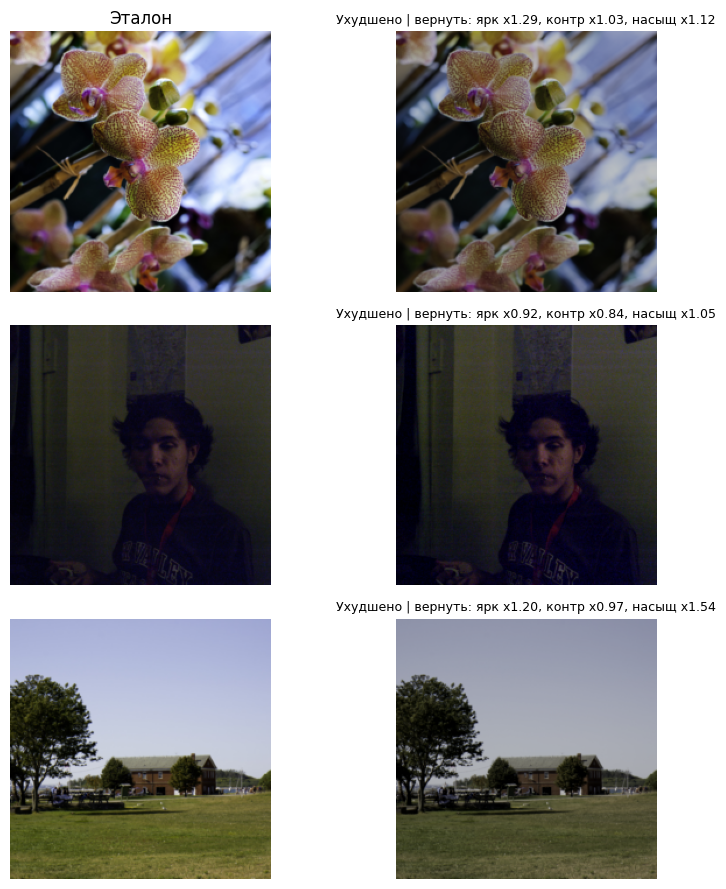

In [31]:
plt.figure(figsize=(9, 9))
for i in range(3):
    arr = load_square(train_df.image_path[int(rng.integers(len(train_df)))], 224).astype(np.float32)/255.0
    fb = float(rng.uniform(*BRIGHTNESS_RANGE)); fc = float(rng.uniform(*CONTRAST_RANGE)); fs = float(rng.uniform(*SATURATION_RANGE))
    bad = np_apply_adjust(arr, fb, fc, fs)
    plt.subplot(3, 2, 2*i+1); plt.imshow(arr); plt.axis("off")
    if i == 0: plt.title("Эталон")
    plt.subplot(3, 2, 2*i+2); plt.imshow(bad); plt.axis("off")
    plt.title(f"Ухудшено | вернуть: ярк x{1/fb:.2f}, контр x{1/fc:.2f}, насыщ x{1/fs:.2f}", fontsize=9)
plt.tight_layout(); plt.show()


# 4. Конвейер подготовки данных

Чтение и декодирование исходных JPEG большого размера на каждом шаге обучения — узкое место по скорости. Поэтому все изображения **один раз** декодируются и приводятся к рабочему размеру, после чего хранятся в оперативной памяти в компактном формате `uint8`. Это многократно ускоряет эпохи обучения.

Для обучающей выборки на каждом проходе применяется **аугментация** — случайный кроп и горизонтальное отражение, а также случайная деградация «на лету». Это увеличивает разнообразие и снижает переобучение. Для валидации и теста деградация **фиксируется** (одна и та же для каждого изображения), чтобы оценка была воспроизводимой.


In [32]:
AUTOTUNE = tf.data.AUTOTUNE

def preload(df, size):
    arr = np.zeros((len(df), size, size, 3), np.uint8)
    for i, p in enumerate(df.image_path):
        arr[i] = load_square(p, size)
    return arr

print("Декодирую изображения в память (выполняется один раз, несколько минут)...")
train_u8 = preload(train_df, TRAIN_BASE)
val_u8   = preload(val_df,   IMG_SIZE)
test_u8  = preload(test_df,  IMG_SIZE)
print("В памяти:", train_u8.shape, val_u8.shape, test_u8.shape,
      "| ~%.2f ГБ" % ((train_u8.nbytes + val_u8.nbytes + test_u8.nbytes)/1e9))


Декодирую изображения в память (выполняется один раз, несколько минут)...
В памяти: (4000, 240, 240, 3) (500, 224, 224, 3) (500, 224, 224, 3) | ~0.84 ГБ


In [33]:
def fixed_factors(n, seed):
    r = np.random.default_rng(seed)
    return (r.uniform(*BRIGHTNESS_RANGE, n).astype("float32"),
            r.uniform(*CONTRAST_RANGE,   n).astype("float32"),
            r.uniform(*SATURATION_RANGE, n).astype("float32"))

def train_map(u8):
    img = tf.cast(u8, tf.float32) / 255.0
    img = tf.image.random_crop(img, [IMG_SIZE, IMG_SIZE, 3])
    img = tf.image.random_flip_left_right(img)
    fb, fc, fs = sample_degradation()
    return apply_adjust(img, fb, fc, fs), encode_restore_target(fb, fc, fs)

def eval_map(u8, fb, fc, fs):
    img = tf.cast(u8, tf.float32) / 255.0
    return apply_adjust(img, fb, fc, fs), encode_restore_target(fb, fc, fs)

train_ds = (tf.data.Dataset.from_tensor_slices(train_u8)
            .shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
            .map(train_map, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))

def eval_ds_from(u8, seed):
    fb, fc, fs = fixed_factors(len(u8), seed)
    return (tf.data.Dataset.from_tensor_slices((u8, fb, fc, fs))
            .map(eval_map, num_parallel_calls=AUTOTUNE).batch(BATCH).prefetch(AUTOTUNE))

val_ds  = eval_ds_from(val_u8,  SEED + 100)
test_ds = eval_ds_from(test_u8, SEED + 200)

for xb, yb in train_ds.take(1):
    print("Размер батча:", xb.shape, "| целей:", yb.shape)


Размер батча: (64, 224, 224, 3) | целей: (64, 3)


# 5. Сравнение семейств моделей

По аналогии с анализом данных Титаника, где сравнивались разные семейства алгоритмов, проведём такое же сравнение и здесь. Сначала установим «планку» простыми классическими моделями, работающими не на изображении целиком, а на наборе **усреднённых признаков**: средняя яркость, контраст, насыщенность, средние значения каналов R/G/B и 10-й и 90-й перцентили яркости (характеризуют динамический диапазон). Это восемь чисел, по которым модель должна предсказать три коэффициента.

Сравним четыре семейства: линейную регрессию, случайный лес, градиентный бустинг (XGBoost) и небольшую нейросеть (MLP) — все на одних и тех же признаках. Это покажет, какого качества можно достичь, опираясь только на глобальную статистику изображения.


In [34]:
def extract_features(arr01):
    luma = 0.299*arr01[..., 0] + 0.587*arr01[..., 1] + 0.114*arr01[..., 2]
    sat  = rgb_to_hsv(arr01)[..., 1]
    return np.array([luma.mean(), luma.std(), sat.mean(),
                     arr01[..., 0].mean(), arr01[..., 1].mean(), arr01[..., 2].mean(),
                     np.percentile(luma, 10), np.percentile(luma, 90)], np.float32)

def build_tabular(df, n_aug, seed, fixed_seed=None):
    X, Y = [], []
    if fixed_seed is None:
        r = np.random.default_rng(seed)
        for p in df.image_path:
            base = load_square(p, 128).astype(np.float32)/255.0
            for _ in range(n_aug):
                fb, fc, fs = r.uniform(*BRIGHTNESS_RANGE), r.uniform(*CONTRAST_RANGE), r.uniform(*SATURATION_RANGE)
                X.append(extract_features(np_apply_adjust(base, fb, fc, fs)))
                Y.append([np.log(1/fb), np.log(1/fc), np.log(1/fs)])
    else:
        fb, fc, fs = fixed_factors(len(df), fixed_seed)
        for i, p in enumerate(df.image_path):
            base = load_square(p, 128).astype(np.float32)/255.0
            X.append(extract_features(np_apply_adjust(base, fb[i], fc[i], fs[i])))
            Y.append([np.log(1/fb[i]), np.log(1/fc[i]), np.log(1/fs[i])])
    return np.array(X, np.float32), np.array(Y, np.float32)

print("Готовлю табличные признаки (несколько минут)...")
X_tr, Y_tr = build_tabular(train_df, n_aug=2, seed=SEED)
X_va, Y_va = build_tabular(val_df, n_aug=1, seed=0, fixed_seed=SEED + 100)
print("Обучающих примеров:", X_tr.shape, "| валидационных:", X_va.shape)


Готовлю табличные признаки (несколько минут)...
Обучающих примеров: (8000, 8) | валидационных: (500, 8)


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras import layers

def coeff_mae(Ylog_true, Ylog_pred):
    t, p = np.exp(Ylog_true), np.exp(Ylog_pred)
    return float(np.abs(t - p).mean()), np.abs(t - p).mean(0)

results = []

# Линейная регрессия и случайный лес
for name, model_ in [("Линейная регрессия", LinearRegression()),
                     ("Случайный лес", RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1))]:
    model_.fit(X_tr, Y_tr)
    overall, per = coeff_mae(Y_va, model_.predict(X_va))
    results.append({"Модель": name, "вход": "8 признаков", "MAE": overall,
                    "яркость": per[0], "контраст": per[1], "насыщенность": per[2]})

# XGBoost (если доступен)
try:
    from xgboost import XGBRegressor
    from sklearn.multioutput import MultiOutputRegressor
    xgb = MultiOutputRegressor(XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=SEED, verbosity=0))
    xgb.fit(X_tr, Y_tr)
    overall, per = coeff_mae(Y_va, xgb.predict(X_va))
    results.append({"Модель": "XGBoost", "вход": "8 признаков", "MAE": overall,
                    "яркость": per[0], "контраст": per[1], "насыщенность": per[2]})
except Exception as e:
    print("XGBoost недоступен:", e)

# Небольшая нейросеть на признаках
fmean, fstd = X_tr.mean(0), X_tr.std(0) + 1e-6
mlp = tf.keras.Sequential([tf.keras.Input((X_tr.shape[1],)),
                           layers.Dense(64, activation="relu"),
                           layers.Dense(32, activation="relu"),
                           layers.Dense(3)])
mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=tf.keras.losses.Huber(0.1))
mlp.fit((X_tr - fmean)/fstd, Y_tr, validation_data=((X_va - fmean)/fstd, Y_va),
        epochs=300, batch_size=128, verbose=0,
        callbacks=[tf.keras.callbacks.EarlyStopping(patience=30, restore_best_weights=True)])
overall, per = coeff_mae(Y_va, mlp.predict((X_va - fmean)/fstd, verbose=0))
results.append({"Модель": "MLP (нейросеть)", "вход": "8 признаков", "MAE": overall,
                "яркость": per[0], "контраст": per[1], "насыщенность": per[2]})

baseline_df = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
display(baseline_df.round(4))


,Модель,вход,MAE,яркость,контраст,насыщенность
0,MLP (нейросеть),8 признаков,0.1369,0.1245,0.0977,0.1885
1,XGBoost,8 признаков,0.1387,0.1261,0.0972,0.1929
2,Случайный лес,8 признаков,0.1399,0.1273,0.0984,0.1940
3,Линейная регрессия,8 признаков,0.1438,0.1305,0.1085,0.1923


## 5.1. Промежуточный вывод

Все классические модели на усреднённых признаках достигают близкого качества — общая ошибка коэффициентов оказывается примерно на одном уровне. Это и есть «потолок» подхода, опирающегося только на глобальную статистику: имея на входе всего несколько усреднённых чисел, точнее предсказать коррекцию принципиально нельзя. Особенно заметно, что хуже всего предсказывается **насыщенность** — её сложно вывести из средних значений.

Логичный следующий шаг — проверить, способна ли модель, которая «видит» изображение целиком, превзойти эту планку, используя его содержимое (а не только усреднённые числа).


# 6. Нейросетевая модель

Классические модели ограничены тем, что видят лишь восемь усреднённых чисел. Свёрточная нейросеть, напротив, анализирует всё изображение и может учитывать его содержание — где расположены тени и света, какие объекты в кадре. Это позволяет точнее оценить, каким был исходный (эталонный) вид кадра, и, как следствие, точнее предсказать коэффициенты коррекции.

### Архитектура

Используется компактная **остаточная свёрточная сеть** на разделимых (separable) свёртках — они дают мало параметров при хорошей выразительности. Остаточные связи (skip-connections) облегчают обучение более глубокой сети. Дополнительно в «голову» модели подаются те же глобальные статистики изображения, что и в классических моделях: это гарантирует, что сеть всегда имеет доступ к абсолютным уровням яркости/контраста/насыщенности (которые свёрточные слои с нормализацией склонны «размывать»), и  гарантирует, что качество не окажется хуже уровня классических моделей. Таким образом, свёрточная часть отвечает за содержание, а ветвь статистик — за абсолютные уровни.

Цель — компактная (порядка одного мегабайта) и быстрая модель, пригодная для запуска в браузере.


In [37]:
from tensorflow.keras import layers, Model, Input

def global_stats_layer(x):
    # Абсолютные статистики кадра подаются в модель напрямую
    mean = tf.reduce_mean(x, axis=[1, 2])                          # средние R,G,B
    std  = tf.math.reduce_std(x, axis=[1, 2])                      # разброс по каналам
    luma = 0.299*x[..., 0] + 0.587*x[..., 1] + 0.114*x[..., 2]
    lmean = tf.reduce_mean(luma, axis=[1, 2])[..., None]           # яркость
    lstd  = tf.math.reduce_std(luma, axis=[1, 2])[..., None]       # контраст
    mx = tf.reduce_max(x, axis=-1); mn = tf.reduce_min(x, axis=-1)
    smean = tf.reduce_mean((mx - mn) / (mx + 1e-6), axis=[1, 2])[..., None]  # насыщенность
    return tf.concat([mean, std, lmean, lstd, smean], axis=-1)     # 9 признаков

def res_block(x, f, stride=1):
    sc = x
    y = layers.SeparableConv2D(f, 3, strides=stride, padding="same", use_bias=False)(x)
    y = layers.BatchNormalization()(y); y = layers.ReLU()(y)
    y = layers.SeparableConv2D(f, 3, padding="same", use_bias=False)(y)
    y = layers.BatchNormalization()(y)
    if stride != 1 or sc.shape[-1] != f:
        sc = layers.Conv2D(f, 1, strides=stride, padding="same", use_bias=False)(x)
        sc = layers.BatchNormalization()(sc)
    return layers.ReLU()(layers.Add()([sc, y]))

def build_model(img_size=IMG_SIZE):
    inp = Input((img_size, img_size, 3))
    stats = layers.Lambda(global_stats_layer, name="global_stats")(inp)

    x = layers.Conv2D(40, 3, strides=2, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = res_block(x, 64,  stride=2)
    x = res_block(x, 96,  stride=2)
    x = res_block(x, 144, stride=2)
    x = res_block(x, 192, stride=2)
    x = res_block(x, 192, stride=1)          # доп. блок для глубины
    x = layers.GlobalAveragePooling2D()(x)

    h = layers.Concatenate()([x, stats])
    h = layers.Dense(128, activation="relu")(h)
    h = layers.Dropout(0.3)(h)
    out = layers.Dense(3, name="log_restore")(h)
    return Model(inp, out, name="photo_enhancer_net")

model = build_model()
model.summary()


Model: "photo_enhancer_net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 112, 112,  │      1,080 │ input_layer_5[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        160 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_27 (ReLU)     │ (None, 112, 112,  │          0 │ batch_normalizat… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_24 │ (None, 56, 56,    │      2,920 │ re_lu_27[0][0]    │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_28 (ReLU)     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 56, 56,    │      2,560 │ re_lu_27[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_25 │ (None, 56, 56,    │      4,672 │ re_lu_28[0][0]    │
│ (SeparableConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ separable_conv2d… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_12 (Add)        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_29 (ReLU)     │ (None, 56, 56,    │          0 │ add_12[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_26 │ (None, 28, 28,    │      6,720 │ re_lu_29[0][0]    │
│ (SeparableConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        384 │ separable_conv2d… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_30 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 28, 28,    │      6,144 │ re_lu_29[0][0]  

 Total params: 290,979 (1.11 MB)

 Trainable params: 287,155 (1.10 MB)

 Non-trainable params: 3,824 (14.94 KB)

### Функция потерь и метрики

В качестве функции потерь используется **Huber** — она устойчива к редким большим ошибкам. Качество измеряется средней абсолютной ошибкой (MAE) уже в пространстве самих коэффициентов (через экспоненту), причём отдельно по каждому каналу — чтобы напрямую сравнивать с классическими моделями.


In [38]:
def coeff_mae_metric(y_true, y_pred):
    return tf.reduce_mean(tf.abs(tf.exp(y_true) - tf.exp(y_pred)))
def bright_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(tf.exp(y_true[:, 0]) - tf.exp(y_pred[:, 0])))
def contrast_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(tf.exp(y_true[:, 1]) - tf.exp(y_pred[:, 1])))
def sat_mae(y_true, y_pred):
    return tf.reduce_mean(tf.abs(tf.exp(y_true[:, 2]) - tf.exp(y_pred[:, 2])))

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss=tf.keras.losses.Huber(0.1),
              metrics=[coeff_mae_metric, bright_mae, contrast_mae, sat_mae])


## 6.1. Обучение

Лучшие по валидации веса сохраняются на Google Drive — это позволяет в дальнейшем не переобучать модель, а сразу загружать готовую. Скорость обучения снижается автоматически при выходе на плато, а ранняя остановка прекращает обучение, когда валидационная метрика перестаёт улучшаться.


In [39]:
BEST_MODEL = str(MODELS_DIR / "photo_enhancer_best.keras")

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(BEST_MODEL, monitor="val_coeff_mae_metric", mode="min",
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_coeff_mae_metric", mode="min",
                                     patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_coeff_mae_metric", mode="min",
                                         factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=90, callbacks=callbacks, verbose=1)

import json
model.save(str(MODELS_DIR / "photo_enhancer_last.keras"))
with open(MODELS_DIR / "history.json", "w") as f:
    json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f)
print("Готово. Лучшая val MAE:", round(min(history.history["val_coeff_mae_metric"]), 4))

Epoch 1/90
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - bright_mae: 0.2989 - coeff_mae_metric: 0.3233 - contrast_mae: 0.3467 - loss: 0.0239 - sat_mae: 0.3243
Epoch 1: val_coeff_mae_metric improved from None to 0.17737, saving model to /content/drive/MyDrive/photo_enhancer/models/photo_enhancer_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/photo_enhancer/models/photo_enhancer_best.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 71s 632ms/step - bright_mae: 0.1921 - coeff_mae_metric: 0.2170 - contrast_mae: 0.2025 - loss: 0.0158 - sat_mae: 0.2565 - val_bright_mae: 0.1552 - val_coeff_mae_metric: 0.1774 - val_contrast_mae: 0.1726 - val_loss: 0.0127 - val_sat_mae: 0.2042 - learning_rate: 0.0010
Epoch 2/90
62/63 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - bright_mae: 0.1311 - coeff_mae_metric: 0.1542 - contrast_mae: 0.1221 - loss: 0.0104 - sat_mae: 0.2093
Epoch 2: val_coeff_mae_metric did not improve from 0.17737
63/63 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - bright_mae: 0.1306 - coeff_mae_metric:

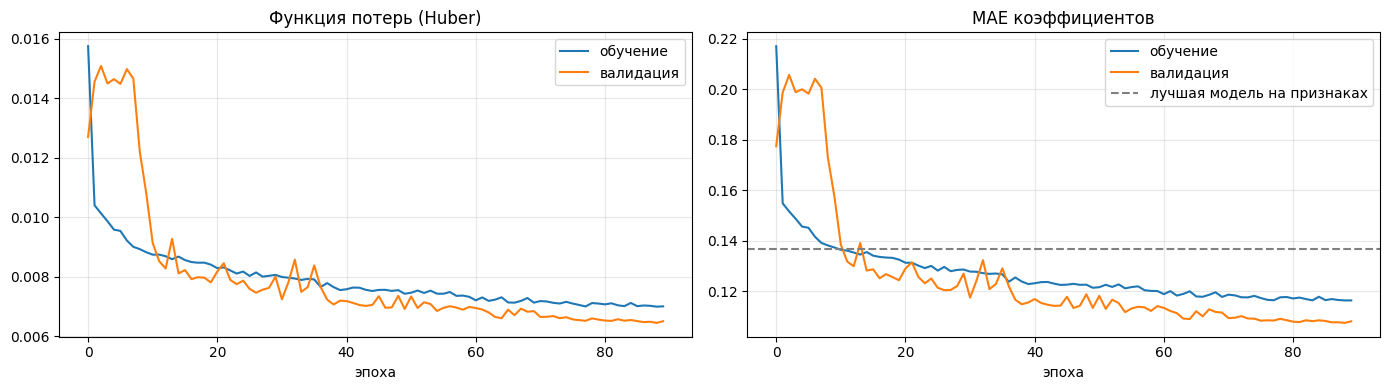

Лучшая валидационная MAE коэффициентов: 0.1075


In [40]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(h["loss"], label="обучение"); ax[0].plot(h["val_loss"], label="валидация")
ax[0].set_title("Функция потерь (Huber)"); ax[0].set_xlabel("эпоха"); ax[0].legend(); ax[0].grid(alpha=.3)

best_baseline = baseline_df["MAE"].min()
ax[1].plot(h["coeff_mae_metric"], label="обучение")
ax[1].plot(h["val_coeff_mae_metric"], label="валидация")
ax[1].axhline(best_baseline, color="gray", linestyle="--", label="лучшая модель на признаках")
ax[1].set_title("MAE коэффициентов"); ax[1].set_xlabel("эпоха"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print("Лучшая валидационная MAE коэффициентов:", round(min(h["val_coeff_mae_metric"]), 4))


## 6.2. Итоговое сравнение моделей

Сведём в одну таблицу результаты всех семейств: классические модели и нейросети на признаках, и нашу свёрточную сеть, работающую с изображением целиком.


In [42]:
cnn = model.evaluate(val_ds, return_dict=True, verbose=0)
cnn_row = {"Модель": "Свёрточная сеть (на изображении)", "вход": "изображение",
           "MAE": cnn["coeff_mae_metric"], "яркость": cnn["bright_mae"],
           "контраст": cnn["contrast_mae"], "насыщенность": cnn["sat_mae"]}

comparison = pd.concat([baseline_df, pd.DataFrame([cnn_row])], ignore_index=True).sort_values("MAE").reset_index(drop=True)
display(comparison.round(4))


,Модель,вход,MAE,яркость,контраст,насыщенность
0,Свёрточная сеть (на изображении),изображение,0.1075,0.0950,0.0649,0.1625
1,MLP (нейросеть),8 признаков,0.1369,0.1245,0.0977,0.1885
2,XGBoost,8 признаков,0.1387,0.1261,0.0972,0.1929
3,Случайный лес,8 признаков,0.1399,0.1273,0.0984,0.1940
4,Линейная регрессия,8 признаков,0.1438,0.1305,0.1085,0.1923


## 6.3. Выводы

Итоговое сравнение семейств подтверждает гипотезу о пользе анализа всего изображения. Модели на восьми усреднённых признаках упираются в общий «потолок» (общая ошибка коэффициентов ≈ 0.137–0.144): по нескольким числам точнее восстановить коррекцию нельзя. Свёрточная сеть, «видящая» содержание кадра, заметно снижает ошибку — **общая MAE ≈ 0.108 против 0.137** у лучшей модели на признаках — и выигрывает по всем трём каналам: яркость 0.095 против 0.124, контраст 0.065 против 0.098, насыщенность 0.162 против 0.189. Наибольший прирост — по яркости и насыщенности, которые сложно вывести из средних значений.

При этом сеть остаётся компактной (около мегабайта) и быстрой, что отвечает требованиям к размеру и производительности решения. Именно её мы берём как итоговую модель для переноса в браузер.

# 7. Оценка качества

Числовая ошибка коэффициентов — полезный ориентир, но итоговое решение оценивается по **качеству изображения**. Поэтому проверим модель тремя способами: визуально (примеры «эталон / ухудшено / восстановлено»), количественно (метрики PSNR и SSIM, измеряющие близость восстановленного к эталону) и на практике — применив модель к произвольным реальным фотографиям.

## 7.1. Визуальная проверка восстановления

Берём тестовые эталоны, искусственно портим их, затем модель по испорченному изображению предсказывает коэффициенты, и мы их применяем. Восстановленное должно быть близко к исходному эталону.

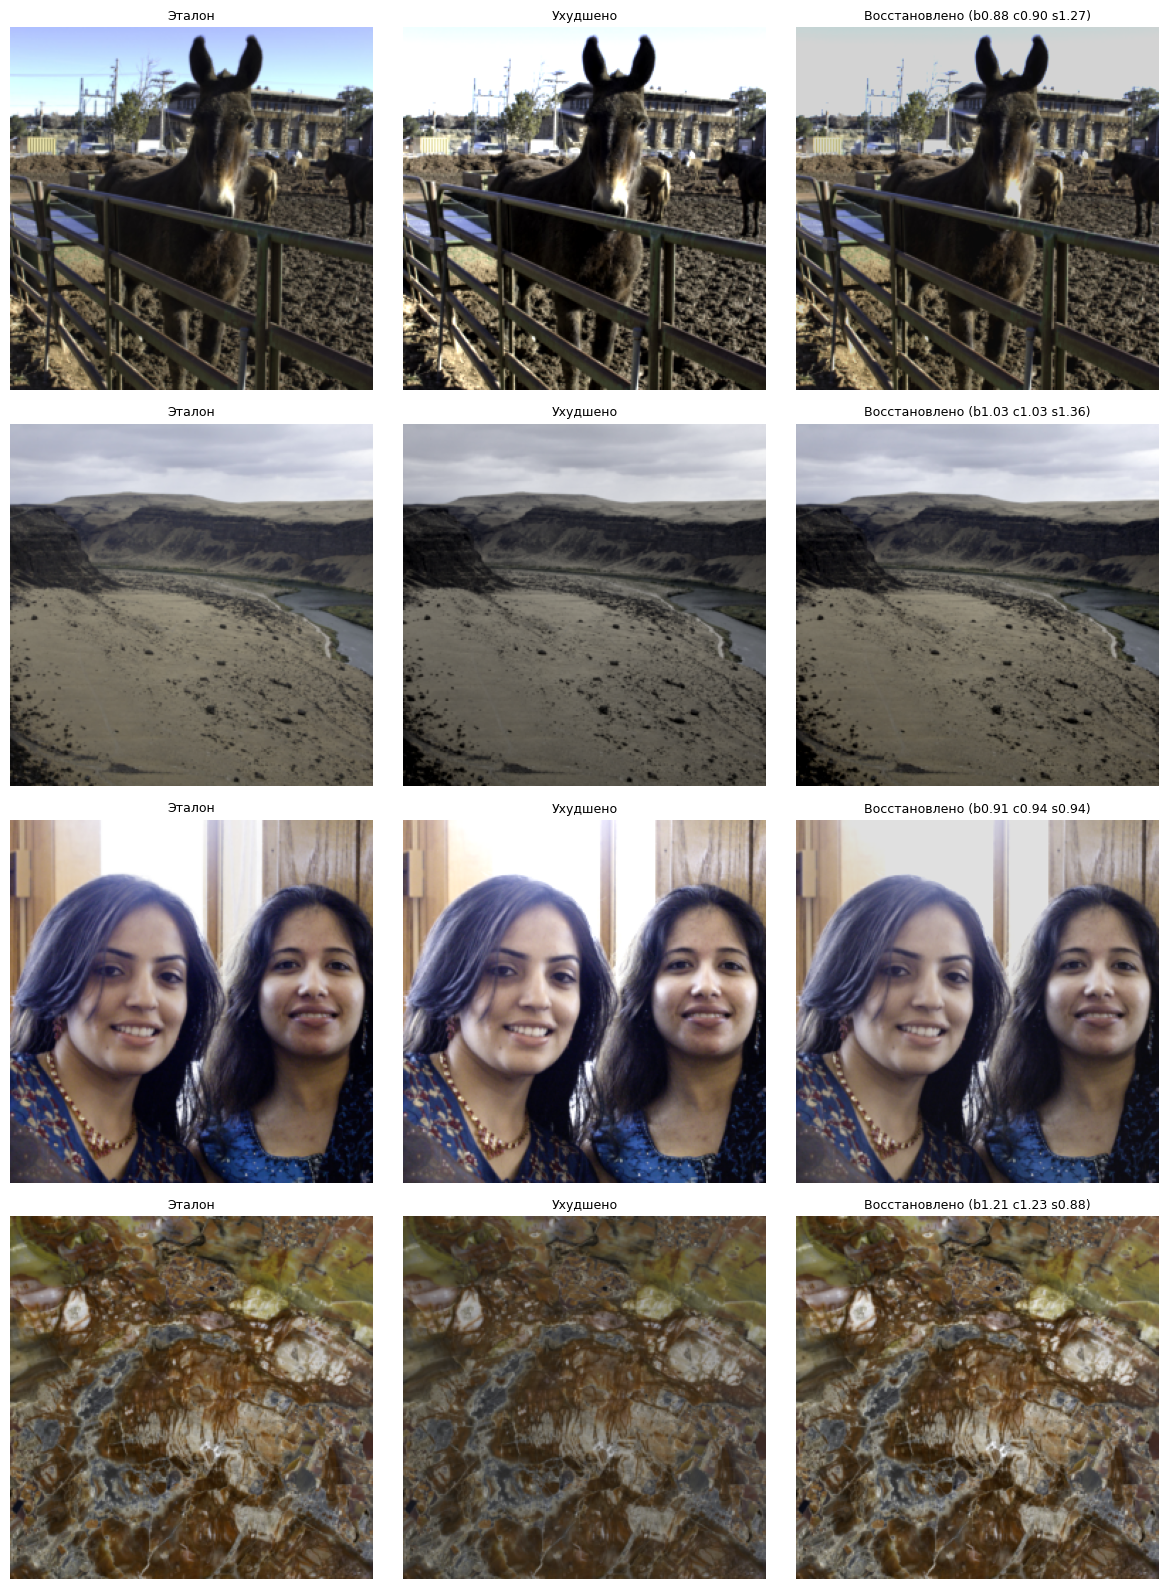

In [43]:
def to_model_input(img01):
    h, w = img01.shape[:2]; s = min(h, w)
    crop = img01[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s]
    return tf.image.resize(crop[None], [IMG_SIZE, IMG_SIZE])

def enhance(img01):
    coeffs = np.exp(model.predict(to_model_input(img01), verbose=0)[0])
    return np_apply_adjust(img01, *coeffs), coeffs

r = np.random.default_rng(7)
plt.figure(figsize=(12, 16))
for i in range(4):
    p = test_df.image_path[int(r.integers(len(test_df)))]
    good = load_square(p, 256).astype(np.float32) / 255.0
    fb, fc, fs = r.uniform(*BRIGHTNESS_RANGE), r.uniform(*CONTRAST_RANGE), r.uniform(*SATURATION_RANGE)
    bad = np_apply_adjust(good, fb, fc, fs)
    restored, coeffs = enhance(bad)
    for k, (im, t) in enumerate([(good, "Эталон"), (bad, "Ухудшено"),
                                 (restored, f"Восстановлено (b{coeffs[0]:.2f} c{coeffs[1]:.2f} s{coeffs[2]:.2f})")]):
        plt.subplot(4, 3, 3*i+k+1); plt.imshow(np.clip(im, 0, 1)); plt.axis("off"); plt.title(t, fontsize=9)
plt.tight_layout(); plt.show()

## 7.2. Количественные метрики: PSNR и SSIM

**PSNR** (пиковое отношение сигнал/шум, дБ — чем больше, тем лучше) и **SSIM** (индекс структурного сходства, от 0 до 1 — чем ближе к 1, тем лучше) измеряют, насколько изображение близко к эталону. Сравним два состояния относительно эталона: ухудшенное и восстановленное моделью. Если модель работает, у восстановленного метрики должны быть заметно выше.

In [44]:
def eval_quality(n=300):
    r = np.random.default_rng(123)
    idx = r.choice(len(test_df), size=min(n, len(test_df)), replace=False)
    goods, bads = [], []
    for j in idx:
        g = load_square(test_df.image_path[j], 224).astype(np.float32) / 255.0
        fb, fc, fs = r.uniform(*BRIGHTNESS_RANGE), r.uniform(*CONTRAST_RANGE), r.uniform(*SATURATION_RANGE)
        goods.append(g); bads.append(np_apply_adjust(g, fb, fc, fs))
    goods, bads = np.stack(goods), np.stack(bads)
    coeffs = np.exp(model.predict(bads, batch_size=64, verbose=0))
    res = np.stack([np_apply_adjust(bads[i], *coeffs[i]) for i in range(len(idx))]).astype(np.float32)

    g, b, rr = tf.constant(goods), tf.constant(bads), tf.constant(res)
    return {
        "PSNR ухудшенного": float(tf.reduce_mean(tf.image.psnr(b, g, 1.0))),
        "PSNR восстановленного": float(tf.reduce_mean(tf.image.psnr(rr, g, 1.0))),
        "SSIM ухудшенного": float(tf.reduce_mean(tf.image.ssim(b, g, 1.0))),
        "SSIM восстановленного": float(tf.reduce_mean(tf.image.ssim(rr, g, 1.0))),
    }

res = eval_quality(300)
for k, v in res.items():
    print(f"{k:26}: {v:.3f}")

PSNR ухудшенного          : 24.923
PSNR восстановленного     : 29.152
SSIM ухудшенного          : 0.926
SSIM восстановленного     : 0.966


## 7.3. Проверка на реальных фотографиях

Главная цель — улучшать произвольные фотографии. Здесь модель применяется к загруженным изображениям напрямую: она предсказывает коэффициенты коррекции, и мы получаем улучшенную версию. (Можно загрузить, например, заведомо «проблемные» снимки — пересвеченные, тусклые, с завалом по цвету.)

Saving f163f3784d0b147d2230fb2968d5bb08.jpg to f163f3784d0b147d2230fb2968d5bb08 (1).jpg


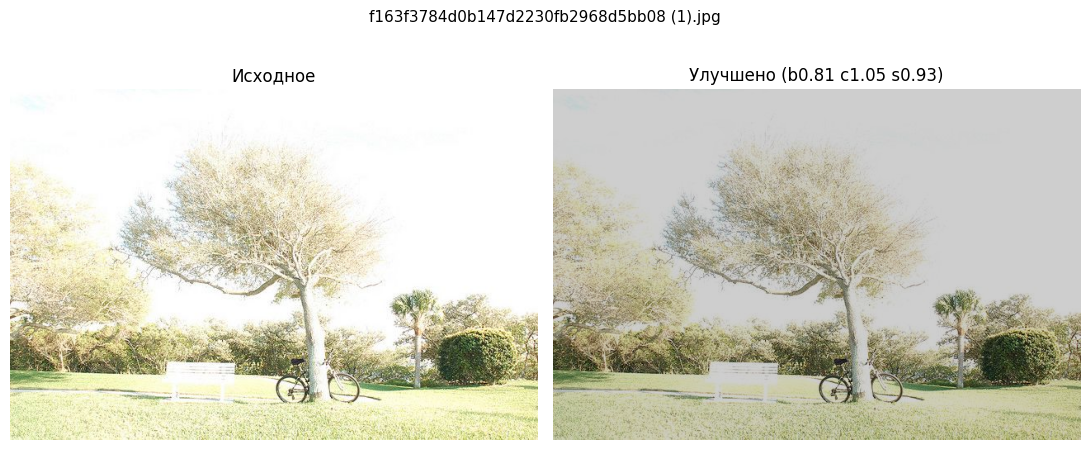

In [50]:
from google.colab import files
uploaded = files.upload()

for name in uploaded:
    arr = np.asarray(Image.open(name).convert("RGB"), np.float32) / 255.0
    enhanced, coeffs = enhance(arr)
    plt.figure(figsize=(11, 5))
    plt.subplot(1, 2, 1); plt.imshow(np.clip(arr, 0, 1)); plt.axis("off"); plt.title("Исходное")
    plt.subplot(1, 2, 2); plt.imshow(np.clip(enhanced, 0, 1)); plt.axis("off")
    plt.title(f"Улучшено (b{coeffs[0]:.2f} c{coeffs[1]:.2f} s{coeffs[2]:.2f})")
    plt.suptitle(name, fontsize=11); plt.tight_layout(); plt.show()

## 7.4. Выводы по оценке качества

Восстановленные изображения значительно ближе к эталону, чем ухудшённые: средний PSNR вырос с ≈24.9 до ≈29.2 дБ, а SSIM — с ≈0.93 до ≈0.97. Значение SSIM выше 0.95 говорит о высокой структурной близости к оригиналу. Это подтверждает, что модель корректно подбирает параметры коррекции, а вспомогательный алгоритм применяет их к изображению с хорошим результатом.

Таким образом, при компактном размере и высокой скорости модель обеспечивает качество, отвечающее цели работы. На последнем шаге остаётся экспортировать её в формат TensorFlow.js для запуска в браузере.

# 8. Экспорт модели в TensorFlow.js

Чтобы модель работала в браузере, её нужно перевести в формат TensorFlow.js. Модель сохраняется в промежуточный формат SavedModel, а затем конвертируется в граф TensorFlow.js. Дополнительно сохраняется небольшой конфигурационный файл с параметрами, которые понадобятся клиентскому коду (размер входа и допустимые диапазоны коэффициентов).

In [52]:
import os, shutil, json, subprocess, sys

print("Устанавливаю tensorflowjs...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "tensorflowjs"],
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

SAVED_DIR = "/content/photo_enhancer_savedmodel"
TFJS_DIR  = "/content/tfjs_model"
for d in (SAVED_DIR, TFJS_DIR):
    if os.path.exists(d): shutil.rmtree(d)

# 1) Промежуточный SavedModel
model.export(SAVED_DIR)

# 2) Конвертация в TensorFlow.js (служебные предупреждения прячем)
res = subprocess.run(
    ["tensorflowjs_converter", "--input_format=tf_saved_model",
     "--output_format=tfjs_graph_model", SAVED_DIR, TFJS_DIR],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

if res.returncode != 0 or not os.path.exists(os.path.join(TFJS_DIR, "model.json")):
    print("Ошибка конвертации:\n", res.stderr[-1500:])
else:
    # 3) Конфигурация для браузера
    config = {
        "img_size": IMG_SIZE,
        "ranges": {"brightness": list(BRIGHTNESS_RANGE),
                   "contrast":   list(CONTRAST_RANGE),
                   "saturation": list(SATURATION_RANGE)},
        "target": "log_restore_coefficients",
        "apply_order": ["brightness (x f)", "contrast (вокруг средней яркости)", "saturation (смешивание с серым)"]
    }
    with open(os.path.join(TFJS_DIR, "inference_config.json"), "w", encoding="utf-8") as f:
        json.dump(config, f, ensure_ascii=False, indent=2)

    # 4) Копируем на Drive и пакуем для скачивания
    dst = MODELS_DIR / "tfjs_model"
    if dst.exists(): shutil.rmtree(dst)
    shutil.copytree(TFJS_DIR, dst)
    shutil.make_archive("/content/tfjs_model", "zip", TFJS_DIR)

    def fmt(b): return f"{b/1024/1024:.2f} МБ" if b >= 1024*1024 else f"{b/1024:.1f} КБ"
    total = 0
    print("\nЭкспорт завершён успешно. Файлы модели TensorFlow.js:")
    for f in sorted(os.listdir(TFJS_DIR)):
        sz = os.path.getsize(os.path.join(TFJS_DIR, f)); total += sz
        print(f"   {f:24} {fmt(sz)}")
    print(f"\n   Итоговый размер модели: {fmt(total)}   (лимит решения — 10 МБ)")
    print("   Сохранено на Google Drive:", dst)
    print("   Архив для скачивания:     /content/tfjs_model.zip")

Устанавливаю tensorflowjs...
Saved artifact at '/content/photo_enhancer_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_152')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  135659955551312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186082000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186078544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186081808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186083728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186082192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186084112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186084304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186084496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135659186081424: TensorSpec(shape